# LSTM Attention Forecasting Benchmark

An LSTM stock price forecasting pipeline that benchmarks a baseline stacked LSTM against an attention-augmented variant, GARCH(1,1), and a naive random walk.


## 1. Install and Import Libraries

In [1]:
!pip install yfinance tensorflow scikit-learn arch matplotlib seaborn pandas numpy shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.4 MB/s eta 0:00:00


In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from arch import arch_model

import shap

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {'primary': '#1a1a2e', 'accent': '#e94560', 'light': '#0f3460', 'neutral': '#a8dadc'}

print(f'TensorFlow version: {tf.__version__}')
print(f'yfinance version: {yf.__version__}')
print('All libraries loaded successfully.')


TensorFlow version: 2.20.0
yfinance version: 0.2.66
All libraries loaded successfully.


## 2. Download and Explore Data

In [3]:
TICKER     = 'SPY'
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'
LOOKBACK   = 60
FORECAST_HORIZON = 1

INTERVAL = '1d'

CACHE_PATH = f'{TICKER}_{START_DATE}_{END_DATE}_{INTERVAL}.csv'

def download_with_retry(ticker, start, end, interval=INTERVAL, max_retries=3, backoff_seconds=5):
    """
    Downloads OHLCV data from yfinance with a few retries on transient
    failures (network blips, Yahoo rate limiting). Raises on the final
    attempt so a failed download is never silently swapped for empty
    or fabricated data.
    """
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            data = yf.download(
                ticker,
                start=start,
                end=end,
                interval=interval,
                auto_adjust=True,
                progress=False,
                multi_level_index=False,
            )
            if data is not None and not data.empty:
                return data
            raise ValueError('yfinance returned an empty dataframe')
        except Exception as exc:
            last_error = exc
            if attempt < max_retries:
                wait = backoff_seconds * attempt
                print(f'Download attempt {attempt} failed ({exc}). Retrying in {wait}s...')
                time.sleep(wait)
    raise RuntimeError(f'yfinance download failed after {max_retries} attempts: {last_error}')

if os.path.exists(CACHE_PATH):
    print(f'Loading cached {TICKER} data from {CACHE_PATH}...')
    raw = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True)
else:
    print(f'Downloading {TICKER} from {START_DATE} to {END_DATE} via yfinance (interval={INTERVAL})...')
    raw = download_with_retry(TICKER, START_DATE, END_DATE, INTERVAL)
    raw.to_csv(CACHE_PATH)
    print(f'Cached to {CACHE_PATH} (delete this file to force a fresh download).')

raw.dropna(inplace=True)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw.columns.name = None

print(f'Shape: {raw.shape}')
print(f'Date range: {raw.index[0].date()} to {raw.index[-1].date()}')
raw.tail()


Cached to SPY_2018-01-01_2024-12-31_1d.csv (delete this file to force a fresh download).
Shape: (1760, 5)
Date range: 2018-01-02 to 2024-12-30


,Close,High,Low,Open,Volume
Date,,,,,
2024-12-23,584.680359,585.280077,577.768657,580.944331,57635800
2024-12-24,591.179138,591.218503,585.447250,586.027345,33160100
2024-12-26,591.218445,592.339211,588.013307,589.409389,41219100
2024-12-27,584.994934,587.718329,580.816469,587.482318,64969300
2024-12-30,578.319275,581.780047,574.573406,577.994873,56578800


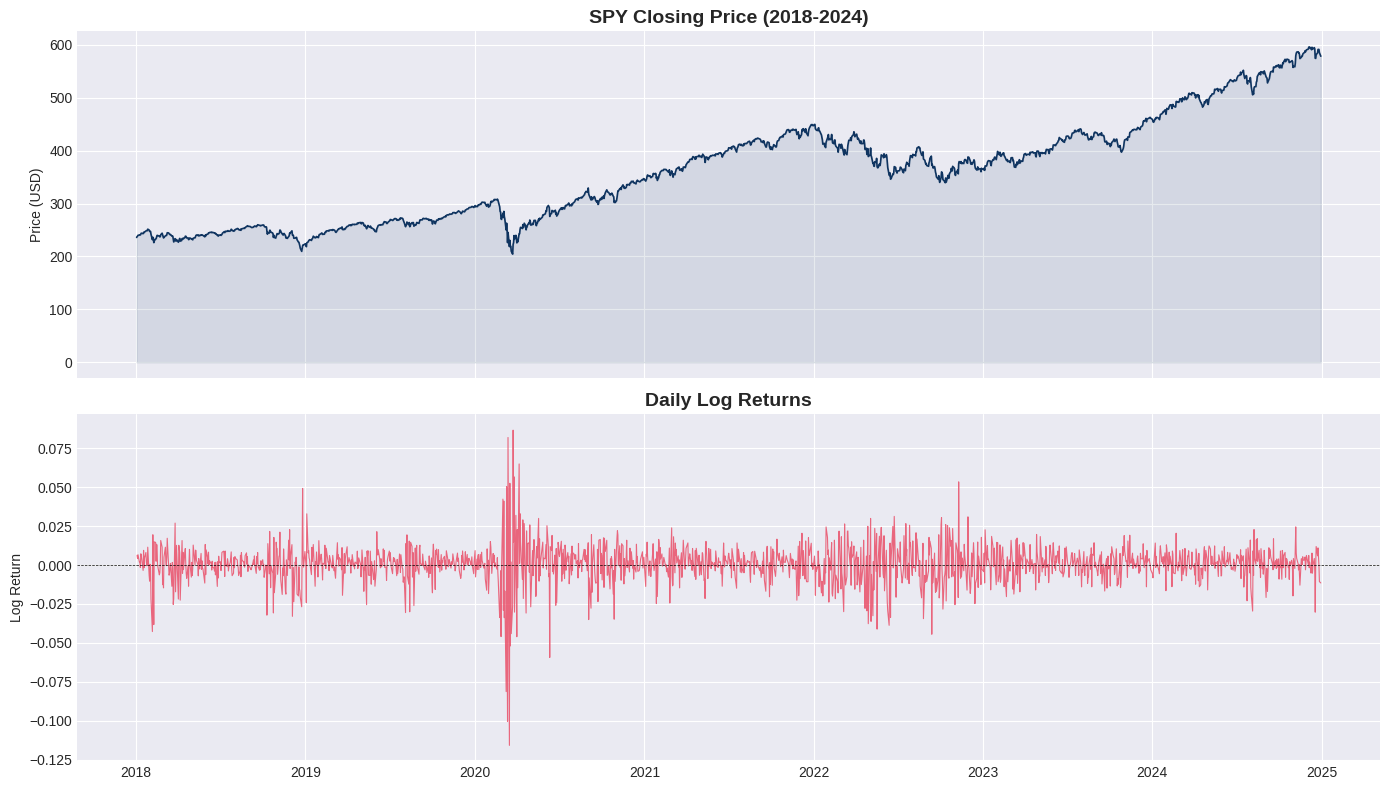

Key events visible: COVID crash (Mar 2020), 2022 bear market, 2023-2024 recovery


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

close_price = raw['Close'].squeeze()

axes[0].plot(raw.index, close_price, color=COLORS['light'], linewidth=1.2)
axes[0].set_title(f'{TICKER} Closing Price (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].fill_between(raw.index, close_price, alpha=0.1, color=COLORS['light'])

raw['Log_Return'] = np.log(close_price / close_price.shift(1))
axes[1].plot(raw.index, raw['Log_Return'], color=COLORS['accent'], linewidth=0.8, alpha=0.8)
axes[1].set_title('Daily Log Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('01_raw_price_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key events visible: COVID crash (Mar 2020), 2022 bear market, 2023-2024 recovery')


## 3. Feature Engineering

In [5]:
def build_features(df):
    """
    Construct technical and statistical features for LSTM input.
    All features use only past data to prevent look-ahead bias.
    """
    data = df.copy()

    data['Log_Return']    = np.log(data['Close'] / data['Close'].shift(1))
    data['HL_Spread']     = np.log(data['High'] / data['Low'])
    data['OC_Return']     = np.log(data['Close'] / data['Open'])

    data['SMA_5']         = data['Close'].rolling(5).mean() / data['Close'] - 1
    data['SMA_20']        = data['Close'].rolling(20).mean() / data['Close'] - 1
    data['SMA_60']        = data['Close'].rolling(60).mean() / data['Close'] - 1
    data['EMA_12']        = data['Close'].ewm(span=12).mean() / data['Close'] - 1
    data['EMA_26']        = data['Close'].ewm(span=26).mean() / data['Close'] - 1
    data['MACD']          = data['EMA_12'] - data['EMA_26']

    data['RV_5']          = data['Log_Return'].rolling(5).std() * np.sqrt(252)
    data['RV_20']         = data['Log_Return'].rolling(20).std() * np.sqrt(252)
    data['RV_60']         = data['Log_Return'].rolling(60).std() * np.sqrt(252)

    data['Vol_Norm']      = (data['Volume'] - data['Volume'].rolling(30).mean()) /\
                             data['Volume'].rolling(30).std()

    delta = data['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    data['RSI']           = 100 - (100 / (1 + rs))
    data['RSI_norm']      = (data['RSI'] - 50) / 50

    data['Ret_lag1']      = data['Log_Return'].shift(1)
    data['Ret_lag5']      = data['Log_Return'].shift(5)
    data['Ret_lag22']     = data['Log_Return'].shift(22)

    data['Target_Price']  = data['Close'].shift(-1)
    data['Target_Return'] = data['Log_Return'].shift(-1)

    return data.dropna()

df = build_features(raw)

FEATURE_COLS = [
    'Log_Return', 'HL_Spread', 'OC_Return',
    'SMA_5', 'SMA_20', 'SMA_60', 'MACD',
    'RV_5', 'RV_20', 'RV_60',
    'Vol_Norm', 'RSI_norm',
    'Ret_lag1', 'Ret_lag5', 'Ret_lag22'
]

TARGET_COL = 'Target_Price'

print(f'Total features: {len(FEATURE_COLS)}')
print(f'Dataset shape after feature engineering: {df.shape}')
print(f'Features: {FEATURE_COLS}')


Total features: 15
Dataset shape after feature engineering: (1699, 25)
Features: ['Log_Return', 'HL_Spread', 'OC_Return', 'SMA_5', 'SMA_20', 'SMA_60', 'MACD', 'RV_5', 'RV_20', 'RV_60', 'Vol_Norm', 'RSI_norm', 'Ret_lag1', 'Ret_lag5', 'Ret_lag22']


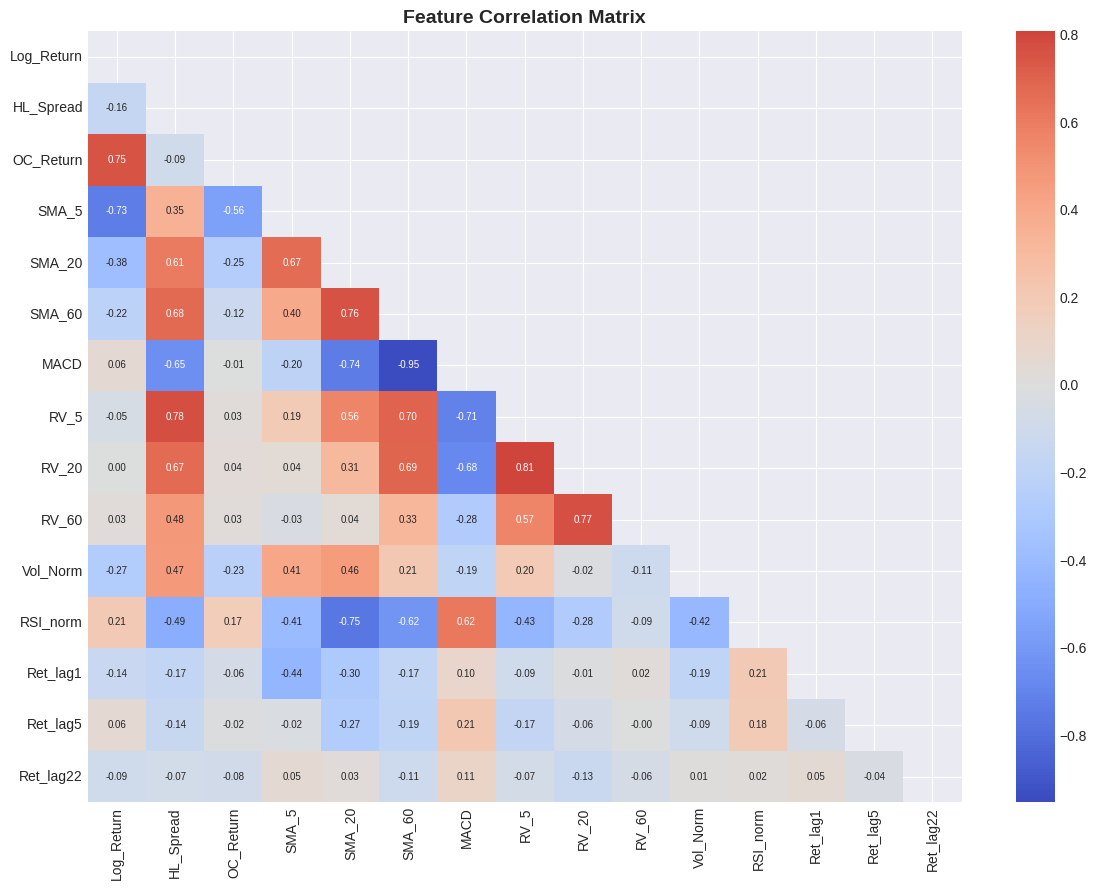

In [6]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Train / Validation / Test Split

In [7]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f'Train:      {train_df.index[0].date()} to {train_df.index[-1].date()}  ({len(train_df)} days)')
print(f'Validation: {val_df.index[0].date()} to {val_df.index[-1].date()}  ({len(val_df)} days)')
print(f'Test:       {test_df.index[0].date()} to {test_df.index[-1].date()}  ({len(test_df)} days)')


Train:      2018-03-29 to 2022-12-15  (1189 days)
Validation: 2022-12-16 to 2023-12-21  (255 days)
Test:       2023-12-22 to 2024-12-27  (255 days)


In [8]:
feat_scaler   = MinMaxScaler(feature_range=(-1, 1))
target_scaler = MinMaxScaler(feature_range=(-1, 1))

X_train_raw = feat_scaler.fit_transform(train_df[FEATURE_COLS])
X_val_raw   = feat_scaler.transform(val_df[FEATURE_COLS])
X_test_raw  = feat_scaler.transform(test_df[FEATURE_COLS])

y_train_raw = target_scaler.fit_transform(train_df[[TARGET_COL]])
y_val_raw   = target_scaler.transform(val_df[[TARGET_COL]])
y_test_raw  = target_scaler.transform(test_df[[TARGET_COL]])

def create_sequences(X, y, lookback):
    """
    Converts flat arrays into overlapping sequences for LSTM input.
    X shape: (samples, features) -> (samples - lookback, lookback, features)

    Vectorised with a sliding window view instead of a Python loop, and
    cast to float32 up front so TensorFlow does not repeatedly cast from
    float64 on every batch. Verified to produce identical output to the
    original per-row loop.
    """
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    windows = sliding_window_view(X, window_shape=lookback, axis=0)
    Xs = windows[:-1].transpose(0, 2, 1)
    ys = y[lookback:]

    return np.ascontiguousarray(Xs), ys

X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK)
X_val,   y_val   = create_sequences(X_val_raw,   y_val_raw,   LOOKBACK)
X_test,  y_test  = create_sequences(X_test_raw,  y_test_raw,  LOOKBACK)

print(f'X_train shape: {X_train.shape}  (samples, lookback, features)')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'dtype: {X_train.dtype}')


X_train shape: (1129, 60, 15)  (samples, lookback, features)
X_val shape:   (195, 60, 15)
X_test shape:  (195, 60, 15)
dtype: float32


## 5. LSTM Model Architecture

In [9]:
def build_lstm_model(input_shape, units=[128, 64, 32], dropout=0.2, lr=1e-3):
    """
    Stacked LSTM with dropout regularisation.

    Architecture:
      Input -> LSTM(128) -> Dropout -> LSTM(64) -> Dropout -> LSTM(32) -> Dropout
           -> Dense(16, ReLU) -> Dropout -> Dense(1, Linear)
    """
    model = Sequential([
        Input(shape=input_shape),

        LSTM(units[0], return_sequences=True, recurrent_dropout=0.1),
        Dropout(dropout),

        LSTM(units[1], return_sequences=True, recurrent_dropout=0.1),
        Dropout(dropout),

        LSTM(units[2], return_sequences=False),
        Dropout(dropout),

        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

tf.keras.backend.clear_session()

INPUT_SHAPE = (LOOKBACK, len(FEATURE_COLS))
model = build_lstm_model(INPUT_SHAPE)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,097 (531.63 KB)

 Trainable params: 136,097 (531.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        min_delta=1e-5,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f'Training stopped at epoch {len(history.history["loss"])}')
print(f'Best validation loss: {min(history.history["val_loss"]):.6f}')


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 285ms/step - loss: 0.2922 - mae: 0.4853 - val_loss: 0.4821 - val_mae: 0.6769 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - loss: 0.2828 - mae: 0.4695 - val_loss: 0.5246 - val_mae: 0.7068 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.2776 - mae: 0.4695 - val_loss: 0.5265 - val_mae: 0.7062 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - loss: 0.2715 - mae: 0.4579 - val_loss: 0.6220 - val_mae: 0.7720 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - loss: 0.2746 - mae: 0.4615 - val_loss: 0.5269 - val_mae: 0.7080 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.2579 - mae: 0.4417
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - loss: 0.2662 - mae: 0.4496 - val_loss: 0.4887 - val_mae: 0.6759 - learning_rate: 

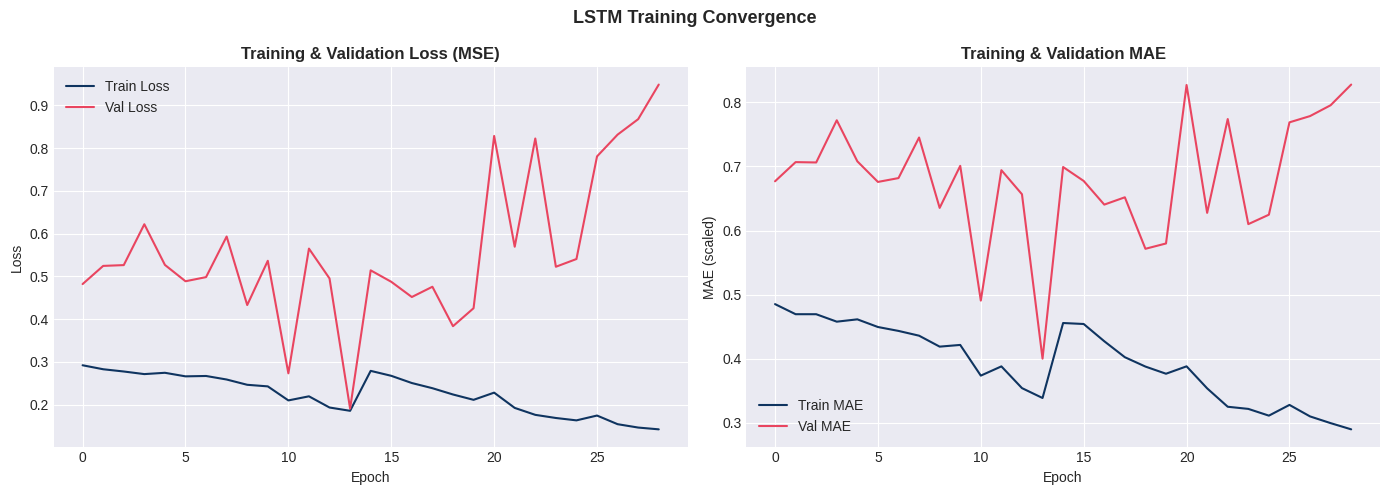

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color=COLORS['light'])
axes[0].plot(history.history['val_loss'], label='Val Loss', color=COLORS['accent'])
axes[0].set_title('Training & Validation Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color=COLORS['light'])
axes[1].plot(history.history['val_mae'], label='Val MAE', color=COLORS['accent'])
axes[1].set_title('Training & Validation MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()

plt.suptitle('LSTM Training Convergence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Evaluation and Predictions

In [12]:
y_pred_scaled = model.predict(X_test, verbose=0)

y_pred = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_true = target_scaler.inverse_transform(y_test).flatten()

test_dates = test_df.index[LOOKBACK:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2   = 1 - ss_res / ss_tot

print('=' * 45)
print('       LSTM TEST SET PERFORMANCE')
print('=' * 45)
print(f'  RMSE : ${rmse:.2f}')
print(f'  MAE  : ${mae:.2f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  R²   : {r2:.4f}')
print('=' * 45)


       LSTM TEST SET PERFORMANCE
  RMSE : $177.02
  MAE  : $174.32
  MAPE : 31.97%
  R²   : -32.3180


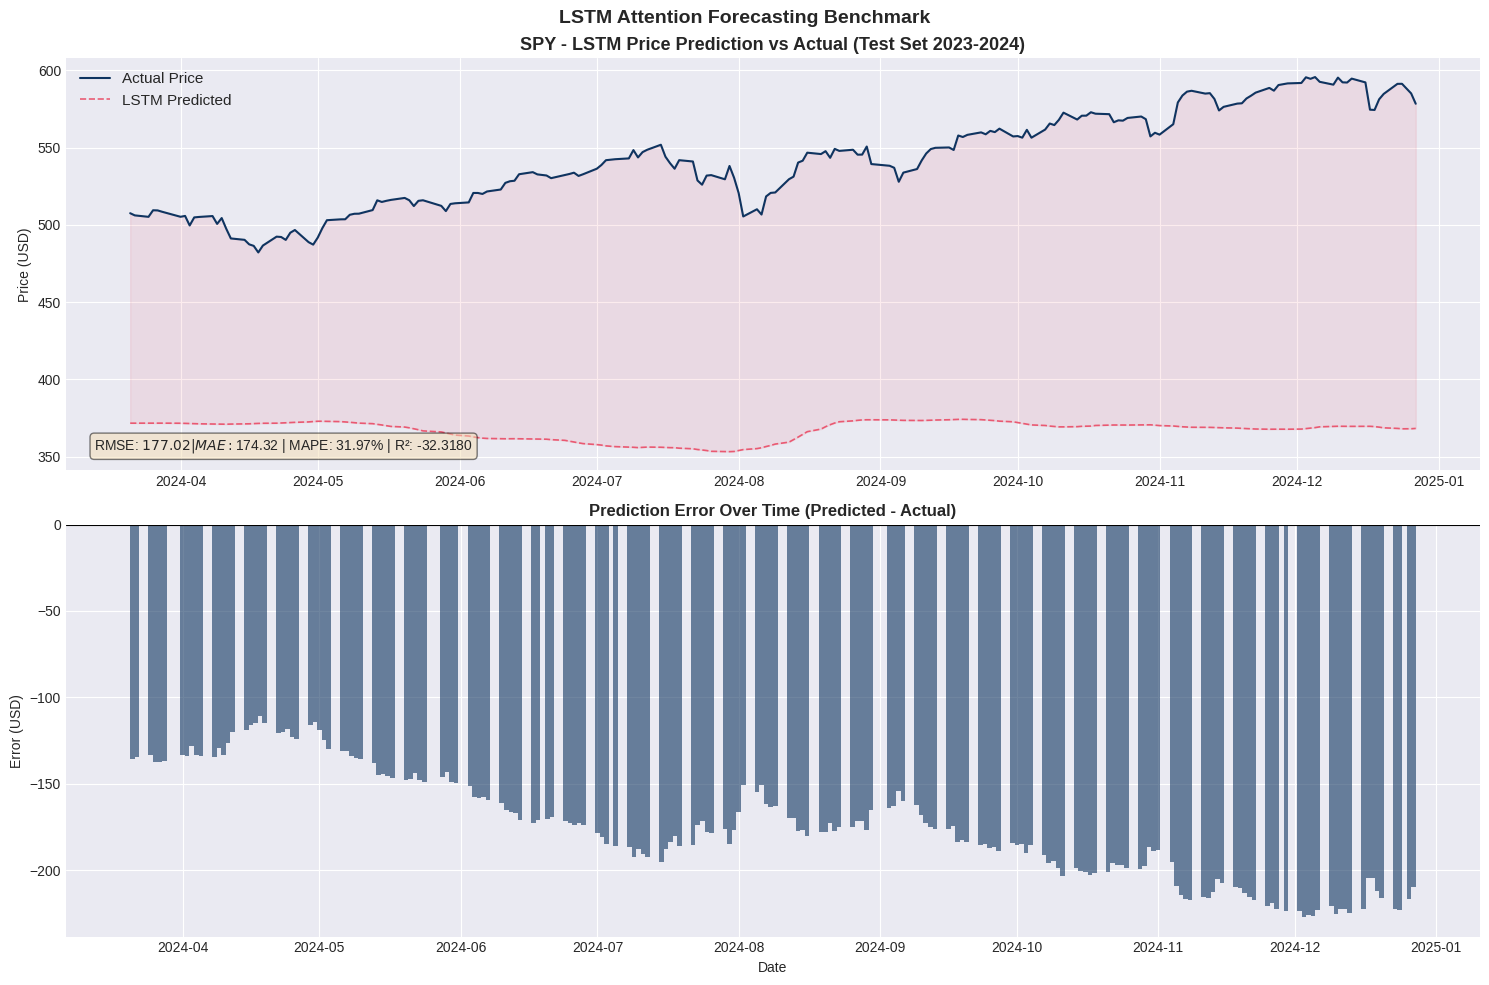

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(test_dates, y_true, label='Actual Price', color=COLORS['light'], linewidth=1.5)
axes[0].plot(test_dates, y_pred, label='LSTM Predicted', color=COLORS['accent'],
             linewidth=1.2, linestyle='--', alpha=0.85)
axes[0].fill_between(test_dates, y_true, y_pred, alpha=0.1, color=COLORS['accent'])
axes[0].set_title(f'{TICKER} - LSTM Price Prediction vs Actual (Test Set 2023-2024)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(fontsize=11)
axes[0].text(0.02, 0.05,
             f'RMSE: ${rmse:.2f} | MAE: ${mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

errors = y_pred - y_true
axes[1].bar(test_dates, errors, color=[
    COLORS['accent'] if e > 0 else COLORS['light'] for e in errors
], alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Prediction Error Over Time (Predicted - Actual)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Error (USD)')
axes[1].set_xlabel('Date')

plt.suptitle('LSTM Attention Forecasting Benchmark', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. GARCH(1,1) Benchmark Comparison


In [14]:
naive_pred = test_df['Close'].values[LOOKBACK-1:-1]
naive_true = y_true

naive_rmse = np.sqrt(mean_squared_error(naive_true, naive_pred))
naive_mae  = mean_absolute_error(naive_true, naive_pred)
naive_mape = np.mean(np.abs((naive_true - naive_pred) / naive_true)) * 100
ss_res_n   = np.sum((naive_true - naive_pred) ** 2)
naive_r2   = 1 - ss_res_n / ss_tot

train_returns_pct = train_df['Log_Return'].dropna() * 100

garch_spec = arch_model(train_returns_pct, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
garch_fit = garch_spec.fit(disp='off')

garch_mean_return = garch_fit.params['mu'] / 100

garch_prev_close = test_df['Close'].values[LOOKBACK-1:-1]
garch_pred = garch_prev_close * np.exp(garch_mean_return)
garch_true = y_true

garch_rmse = np.sqrt(mean_squared_error(garch_true, garch_pred))
garch_mae  = mean_absolute_error(garch_true, garch_pred)
garch_mape = np.mean(np.abs((garch_true - garch_pred) / garch_true)) * 100
ss_res_g   = np.sum((garch_true - garch_pred) ** 2)
garch_r2   = 1 - ss_res_g / ss_tot

n_forecast_steps = len(test_df) - LOOKBACK
garch_vol_forecast = garch_fit.forecast(horizon=n_forecast_steps, reindex=False)
garch_daily_vol = np.sqrt(garch_vol_forecast.variance.values[-1]) / 100
garch_annualised_vol = garch_daily_vol * np.sqrt(252)

print(f'GARCH(1,1) fitted mean daily return: {garch_mean_return*100:.4f}%')
print(f'GARCH(1,1) forecast annualised volatility: {garch_annualised_vol.mean()*100:.2f}% (avg over test window)')

results = pd.DataFrame({
    'Model':      ['Naive (Random Walk)', 'GARCH(1,1)', 'LSTM (Ours)'],
    'RMSE ($)':   [f'{naive_rmse:.2f}', f'{garch_rmse:.2f}', f'{rmse:.2f}'],
    'MAE ($)':    [f'{naive_mae:.2f}',  f'{garch_mae:.2f}',  f'{mae:.2f}'],
    'MAPE (%)':   [f'{naive_mape:.2f}', f'{garch_mape:.2f}', f'{mape:.2f}'],
    'R2':         [f'{naive_r2:.4f}',   f'{garch_r2:.4f}',   f'{r2:.4f}'],
})

print('\n=== MODEL COMPARISON ===')
print(results.to_string(index=False))

rmse_improvement = (naive_rmse - rmse) / naive_rmse * 100
print(f'\nLSTM RMSE improvement over naive baseline: {rmse_improvement:.1f}%')


GARCH(1,1) fitted mean daily return: 0.0984%
GARCH(1,1) forecast annualised volatility: 28.28% (avg over test window)

=== MODEL COMPARISON ===
              Model RMSE ($) MAE ($) MAPE (%)       R2
Naive (Random Walk)     6.43    4.76     0.88   0.9561
         GARCH(1,1)     6.39    4.65     0.86   0.9566
        LSTM (Ours)   177.02  174.32    31.97 -32.3180

LSTM RMSE improvement over naive baseline: -2653.7%


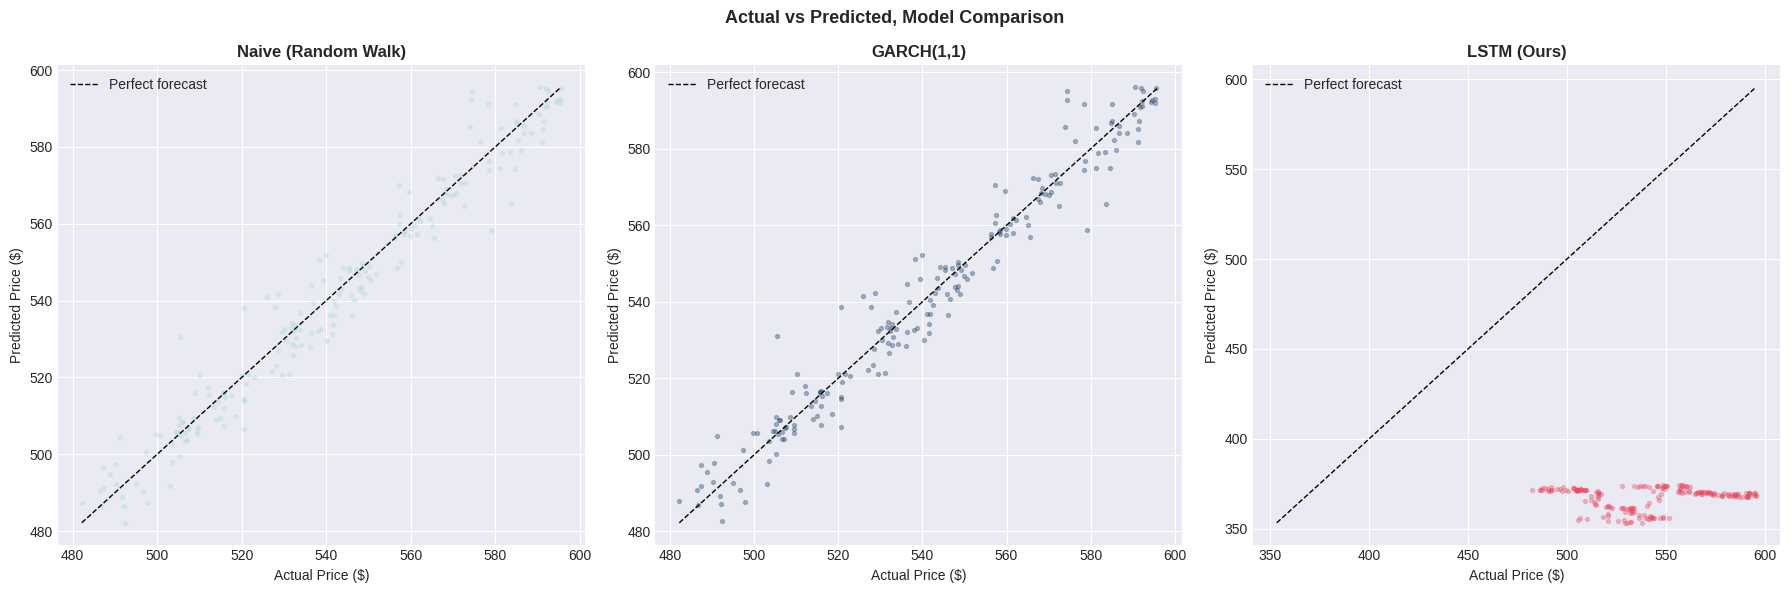

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, true_vals, pred, title, color in zip(
    axes,
    [naive_true, garch_true, y_true],
    [naive_pred, garch_pred, y_pred],
    ['Naive (Random Walk)', 'GARCH(1,1)', 'LSTM (Ours)'],
    [COLORS['neutral'], COLORS['light'], COLORS['accent']]
):
    ax.scatter(true_vals, pred, alpha=0.3, s=8, color=color)
    lims = [min(true_vals.min(), pred.min()), max(true_vals.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect forecast')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted, Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Directional Accuracy (Can the model predict up/down?)

In [16]:
actual_direction  = np.sign(np.diff(y_true))
predicted_direction = np.sign(np.diff(y_pred))

dir_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f'Directional Accuracy: {dir_accuracy:.1f}%')
print(f'(50% = random guessing, >55% = meaningful signal for trading)')

true_up    = np.sum((actual_direction == 1) & (predicted_direction == 1))
true_down  = np.sum((actual_direction == -1) & (predicted_direction == -1))
false_up   = np.sum((actual_direction == -1) & (predicted_direction == 1))
false_down = np.sum((actual_direction == 1) & (predicted_direction == -1))

print(f'\nCorrectly predicted UP days:   {true_up}')
print(f'Correctly predicted DOWN days: {true_down}')
print(f'Predicted UP, was DOWN:        {false_up}')
print(f'Predicted DOWN, was UP:        {false_down}')


Directional Accuracy: 42.3%
(50% = random guessing, >55% = meaningful signal for trading)

Correctly predicted UP days:   39
Correctly predicted DOWN days: 43
Predicted UP, was DOWN:        35
Predicted DOWN, was UP:        77


## 10. Walk-Forward Retraining and Rolling GARCH Refit


In [17]:
RUN_WALK_FORWARD = True
WF_STEP = 21
WF_FINETUNE_EPOCHS = 10
WF_FINETUNE_LR = 1e-4

def walk_forward_lstm(base_model, X_test, y_test, step=WF_STEP,
                       finetune_epochs=WF_FINETUNE_EPOCHS, finetune_lr=WF_FINETUNE_LR):
    """
    Simulates periodic production retraining: the model predicts a block
    of the test period, then, once that block's true values are known,
    is fine-tuned on them (warm start, low learning rate, few epochs)
    before predicting the next block. No block is ever predicted using
    data from later in time.

    This fine-tunes on each new block only, not the full expanding
    history, which is what keeps this fast enough to run inline here;
    a production system might instead retrain on the full history at
    each step, at higher compute cost.
    """
    n = len(X_test)
    wf_pred_scaled = np.zeros((n, 1), dtype=np.float32)

    model_wf = tf.keras.models.clone_model(base_model)
    model_wf.set_weights(base_model.get_weights())
    model_wf.compile(optimizer=Adam(learning_rate=finetune_lr), loss='mse', metrics=['mae'])

    for start in range(0, n, step):
        end = min(start + step, n)
        wf_pred_scaled[start:end] = model_wf.predict(X_test[start:end], verbose=0)
        if end < n:
            model_wf.fit(X_test[start:end], y_test[start:end],
                          epochs=finetune_epochs, batch_size=16, verbose=0)
    return wf_pred_scaled

def rolling_garch(train_returns_pct, all_test_returns, lookback, n_targets, step=WF_STEP):
    """
    Refits GARCH(1,1) every `step` predictions on an expanding window of
    log returns (training history plus every test return revealed so
    far), instead of fitting once on the training window and holding
    those parameters fixed through the whole test period.
    """
    mean_forecasts = np.zeros(n_targets)
    history = list(train_returns_pct)

    for start in range(0, n_targets, step):
        end = min(start + step, n_targets)
        spec = arch_model(pd.Series(history), mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
        fit = spec.fit(disp='off')
        mean_forecasts[start:end] = fit.params['mu'] / 100
        newly_seen = all_test_returns[lookback + start: lookback + end] * 100
        history.extend(newly_seen.tolist())
    return mean_forecasts

if RUN_WALK_FORWARD:
    print(f'Running walk-forward LSTM retraining, refit every {WF_STEP} trading days...')
    wf_pred_scaled = walk_forward_lstm(model, X_test, y_test)
    wf_pred = target_scaler.inverse_transform(wf_pred_scaled).flatten()
    wf_true = y_true

    wf_rmse = np.sqrt(mean_squared_error(wf_true, wf_pred))
    wf_mae  = mean_absolute_error(wf_true, wf_pred)
    wf_mape = np.mean(np.abs((wf_true - wf_pred) / wf_true)) * 100
    ss_res_wf = np.sum((wf_true - wf_pred) ** 2)
    wf_r2 = 1 - ss_res_wf / ss_tot
    wf_dir_accuracy = np.mean(np.sign(np.diff(wf_true)) == np.sign(np.diff(wf_pred))) * 100

    print(f'Running rolling GARCH(1,1) refit, same {WF_STEP}-day cadence...')
    rolling_mean_returns = rolling_garch(
        train_returns_pct.values, test_df['Log_Return'].values, LOOKBACK, len(garch_true), step=WF_STEP
    )
    rolling_garch_pred = garch_prev_close * np.exp(rolling_mean_returns)
    rolling_garch_true = garch_true

    rolling_garch_rmse = np.sqrt(mean_squared_error(rolling_garch_true, rolling_garch_pred))
    rolling_garch_mae  = mean_absolute_error(rolling_garch_true, rolling_garch_pred)
    rolling_garch_mape = np.mean(np.abs((rolling_garch_true - rolling_garch_pred) / rolling_garch_true)) * 100
    ss_res_rg = np.sum((rolling_garch_true - rolling_garch_pred) ** 2)
    rolling_garch_r2 = 1 - ss_res_rg / ss_tot

    print('\n=== STATIC SINGLE FIT vs WALK-FORWARD (refit every {} trading days) ==='.format(WF_STEP))
    print(pd.DataFrame({
        'Model': ['Naive (Random Walk)', 'GARCH(1,1) static', 'GARCH(1,1) walk-forward',
                  'LSTM static', 'LSTM walk-forward'],
        'RMSE ($)': [f'{naive_rmse:.2f}', f'{garch_rmse:.2f}', f'{rolling_garch_rmse:.2f}',
                     f'{rmse:.2f}', f'{wf_rmse:.2f}'],
        'MAE ($)': [f'{naive_mae:.2f}', f'{garch_mae:.2f}', f'{rolling_garch_mae:.2f}',
                    f'{mae:.2f}', f'{wf_mae:.2f}'],
        'MAPE (%)': [f'{naive_mape:.2f}', f'{garch_mape:.2f}', f'{rolling_garch_mape:.2f}',
                     f'{mape:.2f}', f'{wf_mape:.2f}'],
        'R2': [f'{naive_r2:.4f}', f'{garch_r2:.4f}', f'{rolling_garch_r2:.4f}',
               f'{r2:.4f}', f'{wf_r2:.4f}'],
    }).to_string(index=False))
    print(f'\nLSTM directional accuracy, static fit: {dir_accuracy:.1f}%   walk-forward: {wf_dir_accuracy:.1f}%')
else:
    print('RUN_WALK_FORWARD is False, skipping walk-forward retraining (see the config above).')
    wf_pred, wf_true = y_pred, y_true
    rolling_garch_pred, rolling_garch_true = garch_pred, garch_true


Running walk-forward LSTM retraining, refit every 21 trading days...
Running rolling GARCH(1,1) refit, same 21-day cadence...

=== STATIC SINGLE FIT vs WALK-FORWARD (refit every 21 trading days) ===
                  Model RMSE ($) MAE ($) MAPE (%)       R2
    Naive (Random Walk)     6.43    4.76     0.88   0.9561
      GARCH(1,1) static     6.39    4.65     0.86   0.9566
GARCH(1,1) walk-forward     6.39    4.65     0.86   0.9566
            LSTM static   177.02  174.32    31.97 -32.3180
      LSTM walk-forward    93.62   90.59    16.93  -8.3195

LSTM directional accuracy, static fit: 42.3%   walk-forward: 47.9%


## 11. Transaction-Cost-Aware Backtest


In [18]:
TRANSACTION_COST_BPS = 5

prev_close = test_df['Close'].values[LOOKBACK-1:-1]

def backtest_strategy(pred_prices, actual_prices=y_true, prev_prices=prev_close, cost_bps=TRANSACTION_COST_BPS):
    """
    Long when the model expects tomorrow's close to be above today's
    close, flat otherwise. No shorting, no leverage. Turnover-based
    transaction cost is charged whenever the position changes.
    """
    predicted_return = pred_prices / prev_prices - 1
    actual_return = actual_prices / prev_prices - 1

    position = (predicted_return > 0).astype(float)
    position_change = np.abs(np.diff(position, prepend=0.0))
    cost = position_change * (cost_bps / 10000)

    gross_return = position * actual_return
    net_return = gross_return - cost

    equity_curve = np.cumprod(1 + net_return)
    sharpe = np.mean(net_return) / (np.std(net_return) + 1e-12) * np.sqrt(252)
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = equity_curve / running_max - 1

    return {
        'net_return': net_return,
        'equity_curve': equity_curve,
        'sharpe': sharpe,
        'max_drawdown': drawdown.min(),
        'total_return_pct': (equity_curve[-1] - 1) * 100,
        'turnover': position_change.sum(),
    }

strategy_results = {
    'Naive (Random Walk)': backtest_strategy(naive_pred),
    'GARCH(1,1) static': backtest_strategy(garch_pred),
    'GARCH(1,1) walk-forward': backtest_strategy(rolling_garch_pred),
    'LSTM static': backtest_strategy(y_pred),
    'LSTM walk-forward': backtest_strategy(wf_pred),
}

print(f'=== BACKTEST, LONG/FLAT, NET OF {TRANSACTION_COST_BPS} bps TRANSACTION COST ===')
summary = pd.DataFrame({
    'Strategy': list(strategy_results.keys()),
    'Total Return (%)': [f"{r['total_return_pct']:.2f}" for r in strategy_results.values()],
    'Sharpe (ann.)': [f"{r['sharpe']:.2f}" for r in strategy_results.values()],
    'Max Drawdown (%)': [f"{r['max_drawdown']*100:.2f}" for r in strategy_results.values()],
    'Trades': [f"{r['turnover']:.0f}" for r in strategy_results.values()],
})
print(summary.to_string(index=False))


=== BACKTEST, LONG/FLAT, NET OF 5 bps TRANSACTION COST ===
               Strategy Total Return (%) Sharpe (ann.) Max Drawdown (%) Trades
    Naive (Random Walk)             0.00          0.00             0.00      0
      GARCH(1,1) static            31.21          1.97           -14.83      1
GARCH(1,1) walk-forward            31.21          1.97           -14.83      1
            LSTM static             0.00          0.00             0.00      0
      LSTM walk-forward             0.00          0.00             0.00      0


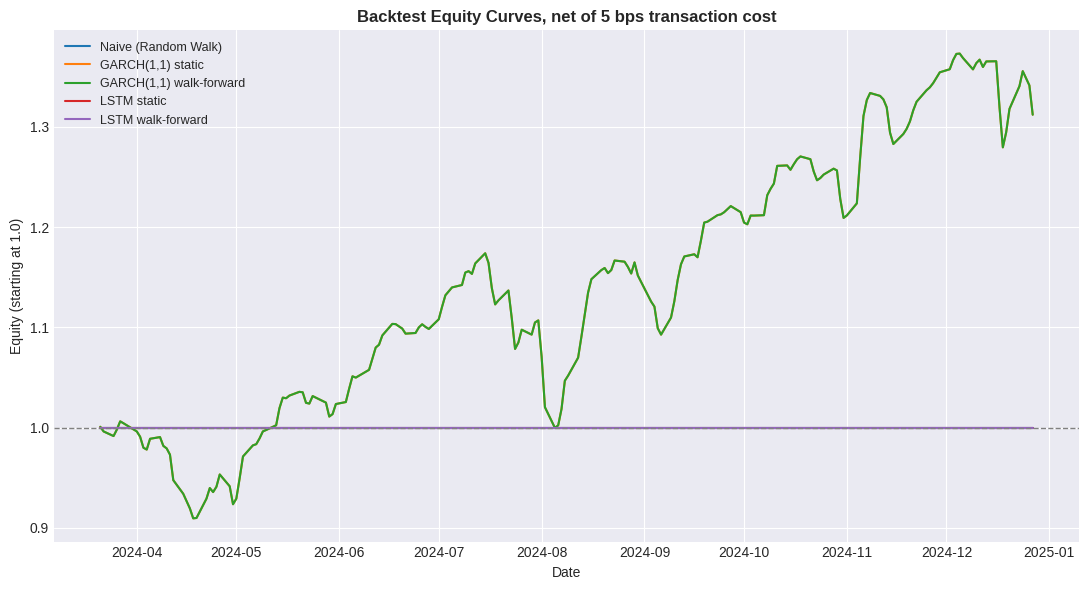

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
for name, r in strategy_results.items():
    ax.plot(test_dates, r['equity_curve'], label=name, linewidth=1.5)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Equity (starting at 1.0)')
ax.set_title(f'Backtest Equity Curves, net of {TRANSACTION_COST_BPS} bps transaction cost', fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('06_backtest_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Regime and Out-of-Distribution Monitor


In [20]:
train_rv20_mean = train_df['RV_20'].mean()
train_rv20_std  = train_df['RV_20'].std()
test_rv20_z = (test_df['RV_20'] - train_rv20_mean) / train_rv20_std

OOD_THRESHOLD = 3.0
ood_flag = test_rv20_z.abs() > OOD_THRESHOLD

print(f'Training-period 20-day realised volatility: mean={train_rv20_mean:.4f}, std={train_rv20_std:.4f}')
print(f'Test-period days flagged as out-of-distribution (|z| > {OOD_THRESHOLD}): {ood_flag.sum()} of {len(ood_flag)}')

if ood_flag.any():
    print('\nFlagged dates:')
    for d in test_df.index[ood_flag]:
        print(f'  {d.date()}')
else:
    print('\nNo test-period days were flagged.')


Training-period 20-day realised volatility: mean=0.1792, std=0.1249
Test-period days flagged as out-of-distribution (|z| > 3.0): 0 of 255

No test-period days were flagged.


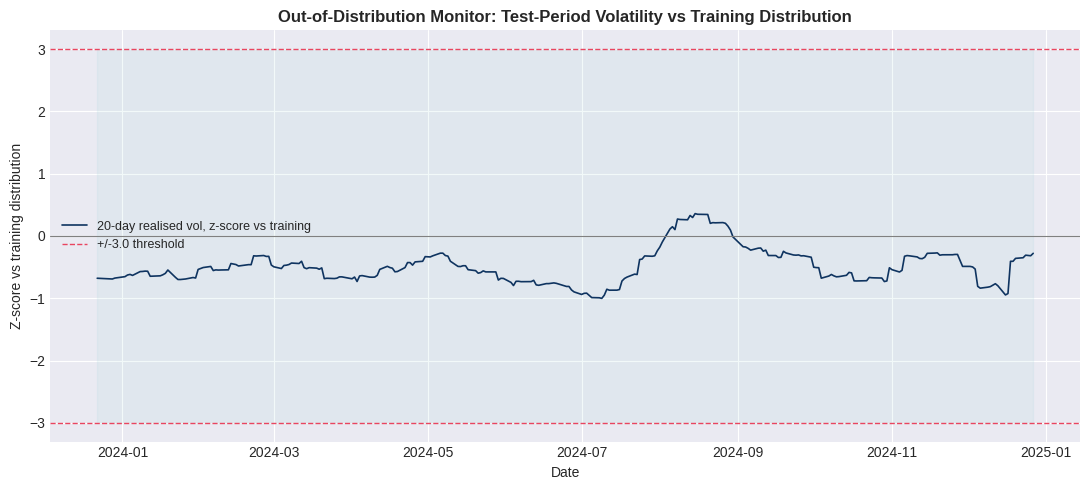

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_df.index, test_rv20_z, color=COLORS['light'], linewidth=1.2, label='20-day realised vol, z-score vs training')
ax.axhline(OOD_THRESHOLD, color=COLORS['accent'], linestyle='--', linewidth=1, label=f'+/-{OOD_THRESHOLD} threshold')
ax.axhline(-OOD_THRESHOLD, color=COLORS['accent'], linestyle='--', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8)
ax.fill_between(test_df.index, -OOD_THRESHOLD, OOD_THRESHOLD, color=COLORS['neutral'], alpha=0.15)
ax.set_xlabel('Date')
ax.set_ylabel('Z-score vs training distribution')
ax.set_title('Out-of-Distribution Monitor: Test-Period Volatility vs Training Distribution', fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('07_ood_monitor.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Attention-Augmented LSTM


In [22]:
from tensorflow.keras.models import Model

def build_attention_lstm_model(input_shape, units=[128, 64, 32], dropout=0.2, lr=1e-3):
    inputs = Input(shape=input_shape)
    x = LSTM(units[0], return_sequences=True, recurrent_dropout=0.1)(inputs)
    x = Dropout(dropout)(x)
    x = LSTM(units[1], return_sequences=True, recurrent_dropout=0.1)(x)
    x = Dropout(dropout)(x)
    lstm_out = LSTM(units[2], return_sequences=True)(x)
    lstm_out = Dropout(dropout)(lstm_out)

    attention_scores  = Dense(1, activation='tanh', name='attn_scores')(lstm_out)
    attention_weights = tf.keras.layers.Softmax(axis=1, name='attn_weights')(attention_scores)
    context = tf.keras.layers.Multiply()([lstm_out, attention_weights])
    context = tf.keras.layers.Lambda(lambda t: tf.reduce_sum(t, axis=1), name='attn_context')(context)

    dense = Dense(16, activation='relu')(context)
    dense = Dropout(0.1)(dense)
    output = Dense(1, activation='linear')(dense)

    model = Model(inputs, output, name='attention_lstm')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

    attention_model = Model(inputs, attention_weights)
    return model, attention_model

tf.keras.backend.clear_session()
attn_lstm, attn_weight_model = build_attention_lstm_model(INPUT_SHAPE)
attn_lstm.summary()


Model: "attention_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 128)   │     73,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 64)    │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 60, 32)    │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 32)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_scores (Dense) │ (None, 60, 1)     │         33 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, 60, 1)     │          0 │ attn_scores[0][0] │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 60, 32)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 32)        │          0 │ multiply[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ attn_context[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 136,130 (531.76 KB)

 Trainable params: 136,130 (531.76 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
attn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        min_delta=1e-5,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

attn_history = attn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=attn_callbacks,
    verbose=1
)

print(f'Training stopped at epoch {len(attn_history.history["loss"])}')
print(f'Best validation loss: {min(attn_history.history["val_loss"]):.6f}')


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 288ms/step - loss: 0.2936 - mae: 0.4866 - val_loss: 0.4970 - val_mae: 0.6869 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - loss: 0.2900 - mae: 0.4797 - val_loss: 0.5602 - val_mae: 0.7309 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - loss: 0.2850 - mae: 0.4703 - val_loss: 0.4986 - val_mae: 0.6883 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - loss: 0.2801 - mae: 0.4674 - val_loss: 0.5623 - val_mae: 0.7326 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - loss: 0.2782 - mae: 0.4613 - val_loss: 0.4944 - val_mae: 0.6834 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - loss: 0.2789 - mae: 0.4567 - val_loss: 0.5407 - val_mae: 0.7171 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - loss: 0.2701 - mae: 0.4541 - val_loss: 0.5743 - val_mae: 0.7380 - learning_rate: 0.0

=== BASELINE STACKED LSTM vs ATTENTION-AUGMENTED LSTM ===
                   Model RMSE ($) MAE ($) MAPE (%)       R2 Directional Accuracy (%)
   Baseline stacked LSTM   177.02  174.32    31.97 -32.3180                     42.3
Attention-augmented LSTM   172.68  160.06    29.22 -30.7072                     57.2


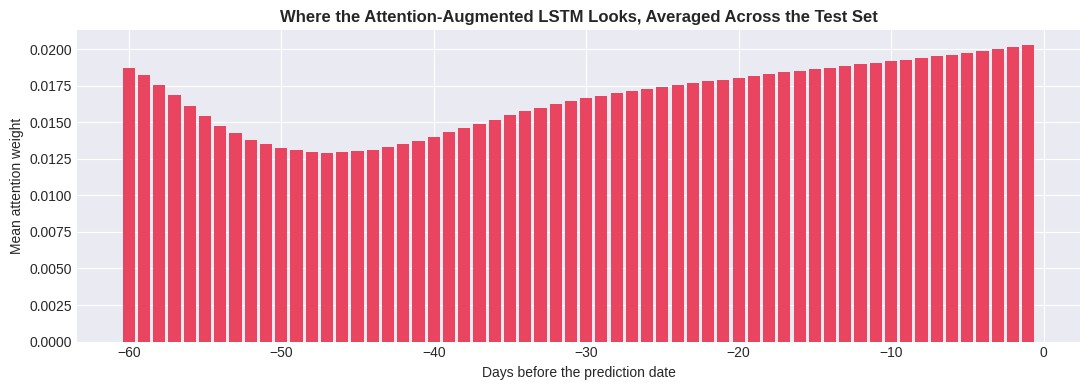

In [24]:
attn_pred_scaled = attn_lstm.predict(X_test, verbose=0)
attn_pred = target_scaler.inverse_transform(attn_pred_scaled).flatten()
attn_true = y_true

attn_rmse = np.sqrt(mean_squared_error(attn_true, attn_pred))
attn_mae  = mean_absolute_error(attn_true, attn_pred)
attn_mape = np.mean(np.abs((attn_true - attn_pred) / attn_true)) * 100
ss_res_a  = np.sum((attn_true - attn_pred) ** 2)
attn_r2   = 1 - ss_res_a / ss_tot
attn_dir_accuracy = np.mean(np.sign(np.diff(attn_true)) == np.sign(np.diff(attn_pred))) * 100

print('=== BASELINE STACKED LSTM vs ATTENTION-AUGMENTED LSTM ===')
print(pd.DataFrame({
    'Model': ['Baseline stacked LSTM', 'Attention-augmented LSTM'],
    'RMSE ($)': [f'{rmse:.2f}', f'{attn_rmse:.2f}'],
    'MAE ($)': [f'{mae:.2f}', f'{attn_mae:.2f}'],
    'MAPE (%)': [f'{mape:.2f}', f'{attn_mape:.2f}'],
    'R2': [f'{r2:.4f}', f'{attn_r2:.4f}'],
    'Directional Accuracy (%)': [f'{dir_accuracy:.1f}', f'{attn_dir_accuracy:.1f}'],
}).to_string(index=False))

attn_weights_test = attn_weight_model.predict(X_test, verbose=0).squeeze(-1)
mean_attn_profile = attn_weights_test.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(-LOOKBACK, 0), mean_attn_profile, color=COLORS['accent'])
ax.set_xlabel('Days before the prediction date')
ax.set_ylabel('Mean attention weight')
ax.set_title('Where the Attention-Augmented LSTM Looks, Averaged Across the Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('08_attention_profile.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Model Interpretability with SHAP


In [25]:
import shap

N_BACKGROUND = 50
N_EXPLAIN    = 100

background = X_train[np.random.choice(len(X_train), N_BACKGROUND, replace=False)]
explain_sample = X_test[:N_EXPLAIN]

explainer = shap.GradientExplainer(model, background)
shap_values = np.array(explainer.shap_values(explain_sample))

print(f'SHAP values computed for {N_EXPLAIN} test predictions, shape {shap_values.shape}')


SHAP values computed for 100 test predictions, shape (100, 60, 15, 1)


=== FEATURE IMPORTANCE (SHAP, GradientExplainer) ===
   Feature  Mean |SHAP value|
  RSI_norm           0.002180
     RV_60           0.001502
    SMA_60           0.000802
  Vol_Norm           0.000702
 OC_Return           0.000657
      MACD           0.000613
    SMA_20           0.000554
     RV_20           0.000490
 HL_Spread           0.000475
      RV_5           0.000297
     SMA_5           0.000278
  Ret_lag5           0.000197
 Ret_lag22           0.000177
  Ret_lag1           0.000163
Log_Return           0.000155


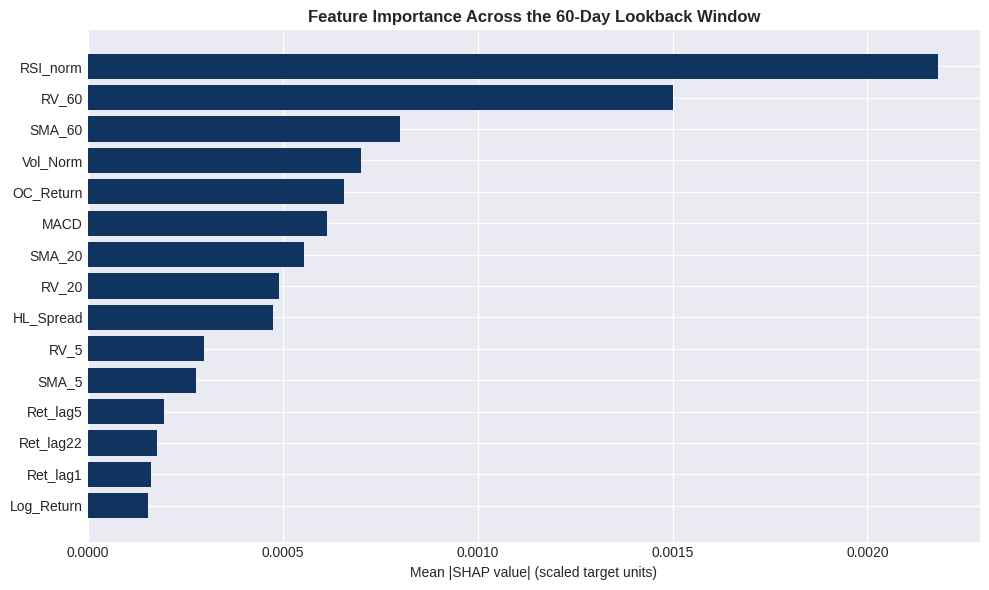

In [26]:
per_feature_importance = np.abs(shap_values).mean(axis=(0, 1, 3))
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean |SHAP value|': per_feature_importance
}).sort_values('Mean |SHAP value|', ascending=False)

print('=== FEATURE IMPORTANCE (SHAP, GradientExplainer) ===')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP value|'][::-1], color=COLORS['light'])
ax.set_xlabel('Mean |SHAP value| (scaled target units)')
ax.set_title('Feature Importance Across the 60-Day Lookback Window', fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


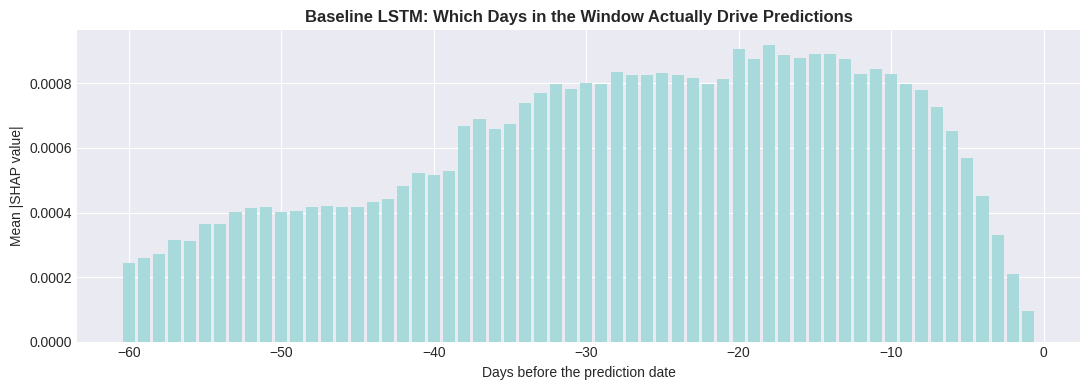

In [27]:
per_day_importance = np.abs(shap_values).mean(axis=(0, 2, 3))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(-LOOKBACK, 0), per_day_importance, color=COLORS['neutral'])
ax.set_xlabel('Days before the prediction date')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Baseline LSTM: Which Days in the Window Actually Drive Predictions', fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_day_importance.png', dpi=150, bbox_inches='tight')
plt.show()
